## **Predictive Modelling: Stroke Risk Classification & Model Evaluation**

The objective of this notebook is to develop machine learning models that predict stroke occurrence using patient demographic, lifestyle, and clinical characteristics.

The models developed in this notebook will help identify high-risk patients and support early intervention strategies.

**This phase includes:**

- Loading the model-ready dataset
- Splitting data into training and testing sets
- Training multiple machine learning models
- Evaluating model performance
- Comparing model effectiveness
- Identifying the most important stroke risk factors
- Exporting the final model for future use

In [10]:
# =====================================================
# STEP 1: IMPORT LIBRARIES
# =====================================================

# Pandas is used for loading and manipulating data.
import pandas as pd

# NumPy supports numerical operations.
import numpy as np

# Used to split data into training and testing sets.
from sklearn.model_selection import train_test_split

# Used to standardize numerical features.
from sklearn.preprocessing import StandardScaler

# Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression

# Model 2: Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Save trained model
import joblib

# **Why This Matters**



Machine learning requires specialized libraries for:
- Data preparation
- Model building
- Evaluation
- Visualization
- Model deployment

In [3]:
# =====================================================
# STEP 2: LOAD MODEL-READY DATASET
# =====================================================

# Load the dataset created during Feature Engineering.

df = pd.read_csv("/content/drive/MyDrive/PERSONAL PROJECTS/MENTORSHIP PROJECTS/1 Stroke Risk Prediction & Clinical Insights Analysis/stroke_model_ready.csv")

# View first records

df.head()

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,...,age_band_40-60,age_band_60+,glucose_risk_Normal,glucose_risk_Pre-Diabetic,glucose_risk_Diabetic,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,stroke
0,67.0,0,1,1,1,228.69,36.6,False,True,False,...,False,True,False,False,True,False,False,False,True,1
1,61.0,0,0,1,0,202.21,28.1,True,False,False,...,False,True,False,False,True,False,False,True,False,1
2,80.0,0,1,1,0,105.92,32.5,False,True,False,...,False,True,False,True,False,False,False,False,True,1
3,49.0,0,0,1,1,171.23,34.4,True,False,False,...,True,False,False,False,True,False,False,False,True,1
4,79.0,1,0,1,0,174.12,24.0,True,False,False,...,False,True,False,False,True,False,True,False,False,1


In [4]:
# Check dataset dimensions

df.shape

(9722, 30)

In [11]:
# =====================================================
# STEP 3: DEFINE FEATURES (X) AND TARGET (y)
# =====================================================

# X contains all variables used to predict stroke.

X = df.drop("stroke", axis=1)

# y contains the outcome we want to predict.

y = df["stroke"]

print(X.shape)
print(y.shape)

(9722, 29)
(9722,)


# **Why This Matters**



Machine learning models learn relationships between:

Predictor Variables (X)
and
Target Variable (y)

In this project:

X = patient characteristics

y = stroke occurrence

# **STEP 4: Train-Test Split**

# **Why Split the Dataset?**

Machine learning models must be evaluated on data they have never seen before.


**Training Set:**
Used to teach the model patterns.


**Testing Set:**
Used to evaluate how well the model generalizes to new patients.


80% Training
20% Testing


Stratification preserves the class distribution across both datasets.

In [12]:
# =====================================================
# STEP 4: TRAIN-TEST SPLIT
# =====================================================

# 80% of data will be used for training.
# 20% will be used for testing.

# stratify=y ensures both datasets maintain
# the same stroke/non-stroke ratio.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (7777, 29)
Testing Set: (1945, 29)


# **Why This Matters**


We must test the model on data it has never seen.

This helps measure how well the model will perform on new patients.

In [13]:
# =====================================================
# STEP 5: FEATURE SCALING
# =====================================================

# Logistic Regression performs better when
# variables are measured on a similar scale.

scaler = StandardScaler()

# Learn scaling parameters from training data
# and transform the training dataset.

X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to testing data.

X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


# **Why This Matters**

Age, BMI, and glucose levels have different ranges.

Scaling prevents large-value variables from dominating the model.

# **MODEL 1: Logistic Regression**

# Model 1: Logistic Regression

Logistic Regression is commonly used in healthcare because:

- Easy to interpret
- Fast to train
- Provides a strong baseline model


This model predicts the probability that a patient experiences a stroke.

In [14]:
# =====================================================
# STEP 6: LOGISTIC REGRESSION MODEL
# =====================================================

# Logistic Regression is a widely used healthcare
# prediction model and serves as a baseline model.

log_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# Train model using scaled data.

log_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression Training Complete")

Logistic Regression Training Complete


In [15]:
## STEP 7: Logistic Regression Predictions
# Generate predictions.

y_pred_log = log_model.predict(
    X_test_scaled
)

In [16]:
## STEP 8: Evaluate Logistic Regression
# =====================================================
# LOGISTIC REGRESSION PERFORMANCE
# =====================================================

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_log)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_log)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_log)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_log)
)

Accuracy: 0.9547557840616967
Precision: 0.982532751091703
Recall: 0.9259259259259259
F1 Score: 0.9533898305084746


In [17]:
# Detailed classification report.

print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.93      0.98      0.96       973
           1       0.98      0.93      0.95       972

    accuracy                           0.95      1945
   macro avg       0.96      0.95      0.95      1945
weighted avg       0.96      0.95      0.95      1945



# **Interpretation**


**Accuracy:**
Overall prediction correctness.


**Precision:**
Of all predicted stroke cases,
how many were actually stroke patients?


**Recall:**
Of all actual stroke patients,
how many did the model correctly identify?

**F1 Score:**
Balances Precision and Recall.

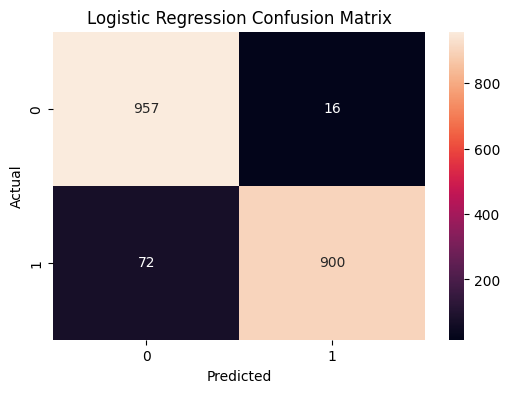

In [18]:
## STEP 9: Logistic Regression Confusion Matrix

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred_log
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [19]:
## STEP 10: Train Random Forest
# =====================================================
# RANDOM FOREST MODEL
# =====================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest Training Complete")

Random Forest Training Complete


# **Why This Matters**


Random Forest can capture complex relationships
between patient characteristics and stroke risk.

In [20]:
## STEP 11: Random Forest Predictions
# Generate predictions.

y_pred_rf = rf_model.predict(
    X_test
)

In [21]:
## SECTION 12: Evaluate Random Forest

# =====================================================
# RANDOM FOREST PERFORMANCE
# =====================================================

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_rf)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_rf)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_rf)
)

Accuracy: 0.9737789203084833
Precision: 0.9801876955161627
Recall: 0.9670781893004116
F1 Score: 0.9735888140859659


In [22]:
# Detailed report.

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       973
           1       0.98      0.97      0.97       972

    accuracy                           0.97      1945
   macro avg       0.97      0.97      0.97      1945
weighted avg       0.97      0.97      0.97      1945



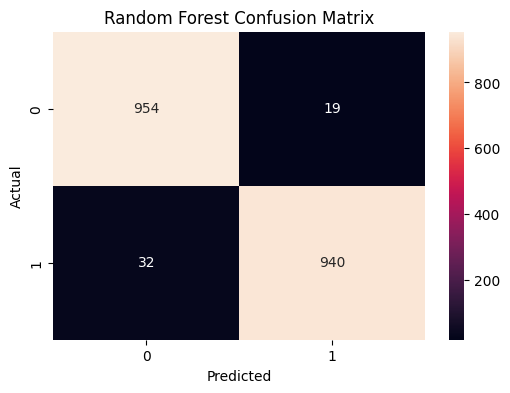

In [23]:
## STEP 13: Random Forest Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [24]:
## STEP 14: ROC Curve Comparison
# =====================================================
# ROC CURVE COMPARISON
# =====================================================

log_probs = log_model.predict_proba(
    X_test_scaled
)[:,1]

rf_probs = rf_model.predict_proba(
    X_test
)[:,1]

In [25]:
# Calculate AUC scores.

log_auc = roc_auc_score(
    y_test,
    log_probs
)

rf_auc = roc_auc_score(
    y_test,
    rf_probs
)

print("Logistic Regression AUC:", log_auc)
print("Random Forest AUC:", rf_auc)

Logistic Regression AUC: 0.989615714835539
Random Forest AUC: 0.9971599440024699


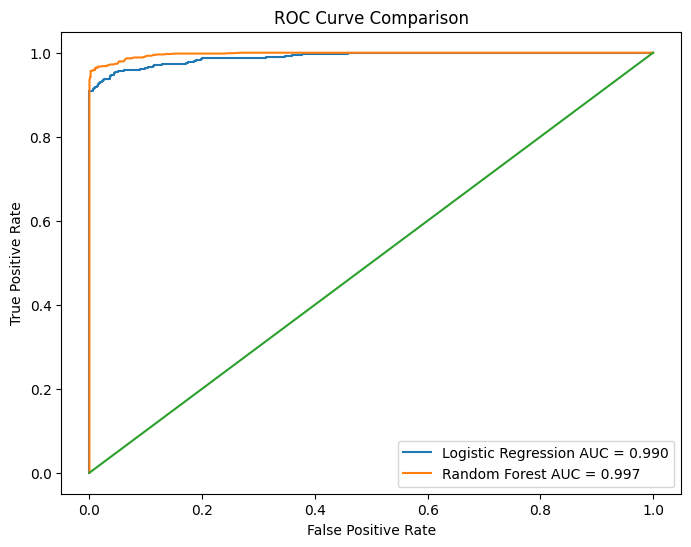

In [26]:
# Build ROC curves.

fpr_log, tpr_log, _ = roc_curve(
    y_test,
    log_probs
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression AUC = {log_auc:.3f}"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC = {rf_auc:.3f}"
)

plt.plot([0,1],[0,1])

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [27]:
## SECTION 15: Feature Importance
# =====================================================
# FEATURE IMPORTANCE
# =====================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,age,0.197488
21,age_band_60+,0.098339
5,avg_glucose_level,0.088382
6,bmi,0.071655
19,age_band_< 40,0.057417
27,bmi_category_Overweight,0.052183
12,work_type_Private,0.043542
16,smoking_status_formerly smoked,0.041250
8,gender_Male,0.038654
7,gender_Female,0.037092


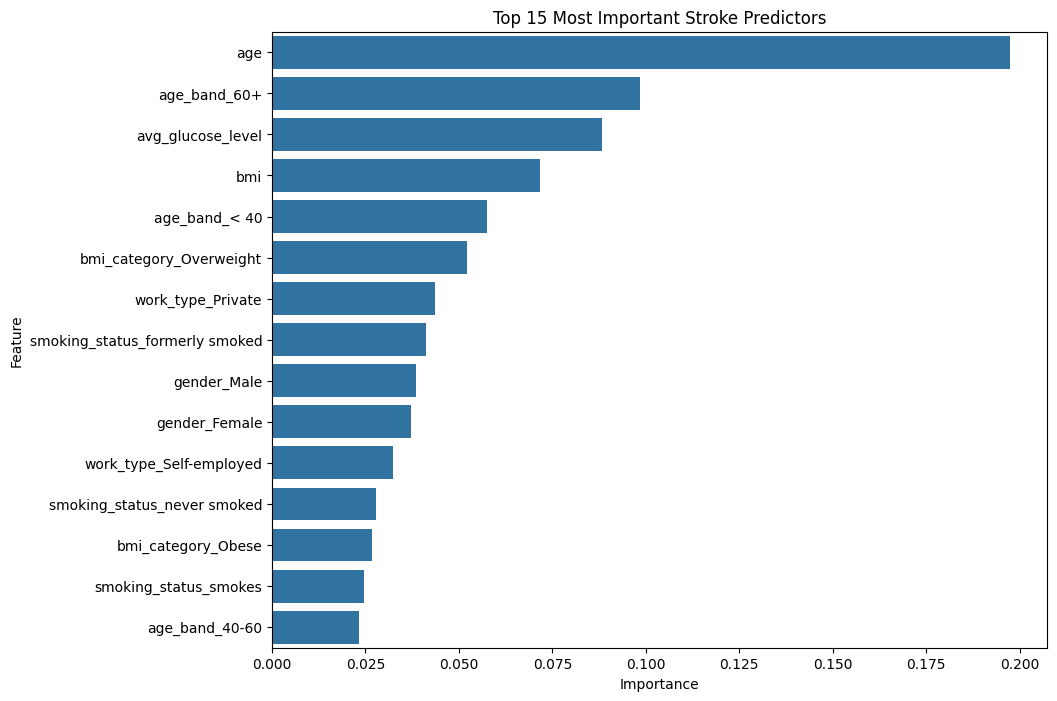

In [28]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Most Important Stroke Predictors"
)

plt.show()

In [29]:
## STEP 16: Save Final Model
# =====================================================
# SAVE FINAL MODEL
# =====================================================

joblib.dump(
    rf_model,
    "stroke_risk_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [30]:
# =====================================================
# EXPORT FINAL MODEL
# =====================================================

import joblib

joblib.dump(
    rf_model,
    "stroke_risk_model.pkl"
)

print("Model exported successfully.")

Model exported successfully.


In [31]:
from google.colab import files

files.download("stroke_risk_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Model Selection**

Two machine learning models were developed and evaluated for stroke risk prediction:

1. Logistic Regression
2. Random Forest Classifier

Both models demonstrated excellent predictive performance. However, Random Forest consistently outperformed Logistic Regression across the most important evaluation metrics.


# **Performance Comparison**

| Metric          | Logistic Regression | Random Forest |
| --------------- | ------------------- | ------------- |
| Accuracy        | 95.5%               | 97.4%         |
| Precision       | 98.3%               | 98.0%         |
| Recall          | 92.6%               | 96.7%         |
| AUC             | 0.990               | 0.997         |
| False Negatives | 72                  | 32            |


### **Selected Model: Random Forest Classifier**


Random Forest was selected as the final model because it achieved:

* Higher overall accuracy
* Higher recall (sensitivity)
* Lower false negative rate
* Higher ROC-AUC score


In healthcare prediction problems, recall is particularly important because failing to identify a patient at risk of stroke may have serious clinical consequences.

The Random Forest model reduced false negatives by approximately 56% compared to Logistic Regression while maintaining similarly high precision.

Based on these results, Random Forest provides the strongest balance between predictive performance and clinical usefulness and was therefore selected as the final model for deployment.




# **Model Limitations**

Although the model achieved excellent predictive performance, several limitations should be acknowledged.

### **1. Dataset Size**

The dataset contains 5,110 patient records, which is relatively small for healthcare machine learning applications. Larger datasets would likely improve model robustness and generalizability.

### **2. Synthetic Data Generation Using SMOTE**

To address class imbalance, SMOTE was applied during feature engineering. While this improves model learning, synthetic observations may not perfectly represent real patient characteristics.

### **3. Limited Clinical Variables**

Several important stroke risk factors were not available in the dataset, including:

* Cholesterol levels
* Physical activity
* Family medical history
* Alcohol consumption
* Medication history

Including these variables could improve predictive accuracy.

### **4. Lack of External Validation**

The model was evaluated on a holdout test set from the same dataset. Validation using independent hospital datasets would provide stronger evidence of real-world performance.

---



### **Model Optimization**

Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV to further improve model performance.

### **Cross-Validation**

Implement k-fold cross-validation to obtain more reliable performance estimates.

### **Advanced Machine Learning Models**

Compare performance against:

* XGBoost
* LightGBM
* CatBoost

### **Model Deployment**

Develop an interactive stroke risk prediction application using:

* Streamlit
* Power BI
* Flask API

### **Real-World Healthcare Validation**

Evaluate model performance using additional clinical datasets from hospitals and healthcare institutions.

---

## **Conclusion**

The Random Forest model demonstrated excellent performance in predicting stroke occurrence and successfully identified key risk factors such as age, glucose level, BMI, and smoking history. With additional data and external validation, the model could serve as a valuable tool for supporting early stroke risk assessment and preventive healthcare interventions.
